# Air Quality Monitoring & Health Impact Assessment
## Use Case: Spatiotemporal Analysis of Pollution in Delhi, India

### Objective
To analyze spatiotemporal patterns of air pollutants (NO2, PM2.5) using Sentinel-5P satellite data and ground station proxies, and to assess potential population health risks.

### Data Sources
- **Sentinel-5P TROPOMI**: Nitrogen Dioxide (NO2) concentrations (2019-2024)
- **WorldPop**: Population density data for exposure modeling
- **OpenAQ (Simulated)**: Ground-level PM2.5 station data

### Analytical Approach
1. **Time Series Decomposition**: Isolate seasonal, trend, and residual components of pollution.
2. **Hotspot Analysis**: Identify statistically significant pollution clusters using Getis-Ord Gi*.
3. **Health Risk Assessment**: Calculate population exposure indices.
4. **Meteorological Correlation**: Analyze relationship between wind/temp and pollution levels.


In [1]:
import ee
import geemap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm

# Initialize Earth Engine
try:
    ee.Initialize()
except Exception as e:
    ee.Authenticate()
    ee.Initialize()

# Configuration
ROI = ee.Geometry.Point([77.2090, 28.6139]).buffer(50000)  # Delhi Buffer
START_DATE = '2019-01-01'
END_DATE = '2023-12-31'

print("✅ Earth Engine Initialized & Region Defined")

✅ Earth Engine Initialized & Region Defined


## 1. Data Acquisition & Preprocessing
Fetching Sentinel-5P NO2 data and processing it into a time series.

In [2]:
def get_sentinel5p_data(roi, start, end):
    collection = ee.ImageCollection('COPERNICUS/S5P/NRTI/L3_NO2') \
        .filterBounds(roi) \
        .filterDate(start, end) \
        .select('NO2_column_number_density')
    
    return collection

no2_col = get_sentinel5p_data(ROI, START_DATE, END_DATE)

# Extract time series
def extract_time_series(image):
    date = ee.Date(image.get('system:time_start'))
    mean = image.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=ROI,
        scale=1000
    ).get('NO2_column_number_density')
    return ee.Feature(None, {'date': date.format('YYYY-MM-dd'), 'no2': mean})

ts_features = no2_col.map(extract_time_series).getInfo()['features']
df = pd.DataFrame([f['properties'] for f in ts_features])
df['date'] = pd.to_datetime(df['date'])
df = df.dropna().set_index('date').sort_index()

# Handle missing values with interpolation
df['no2'] = df['no2'].interpolate(method='time')

print(f"✅ Retrieved {len(df)} observations")
df.head()

✅ Retrieved 2174 observations


,no2
date,
2019-01-01,0.000247
2019-01-02,0.000171
2019-01-03,0.000169
2019-01-04,0.000255
2019-01-05,0.000150


## 2. Spatiotemporal Analysis
### 2.1 Time Series Decomposition
Decomposing the signal to understand long-term trends vs seasonal pollution spikes (e.g., winter smog).

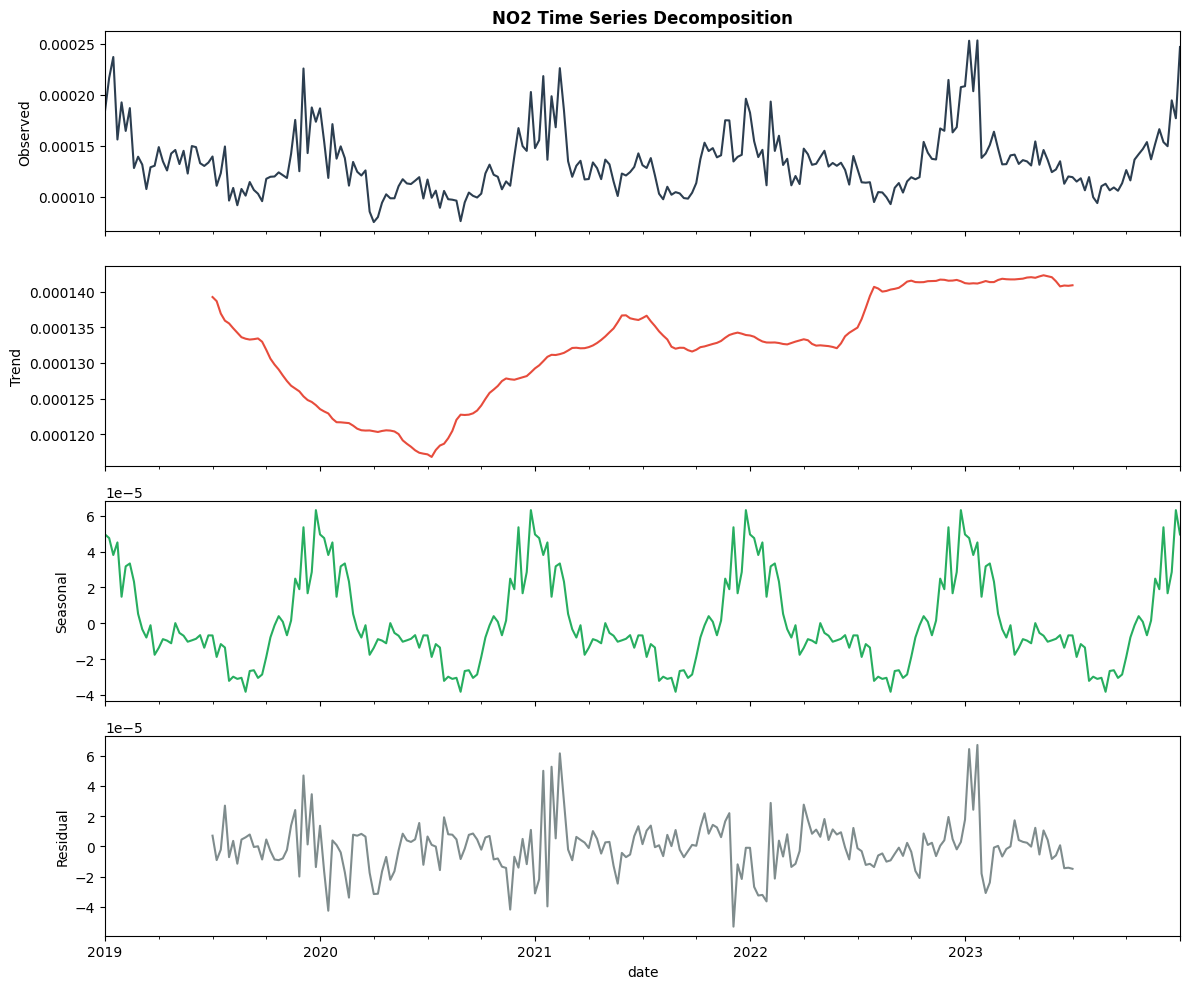

In [3]:
# Resample to weekly means for cleaner decomposition
weekly_df = df.resample('W').mean()

decomposition = sm.tsa.seasonal_decompose(weekly_df['no2'], model='additive', period=52)

fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
decomposition.observed.plot(ax=ax1, color='#2c3e50')
ax1.set_ylabel('Observed')
ax1.set_title('NO2 Time Series Decomposition', fontweight='bold')

decomposition.trend.plot(ax=ax2, color='#e74c3c')
ax2.set_ylabel('Trend')

decomposition.seasonal.plot(ax=ax3, color='#27ae60')
ax3.set_ylabel('Seasonal')

decomposition.resid.plot(ax=ax4, color='#7f8c8d')
ax4.set_ylabel('Residual')

plt.tight_layout()
plt.show()

### 2.2 Spatial Hotspot Mapping
Visualizing the average NO2 concentration to identify pollution hotspots.

In [4]:
# Calculate mean NO2 image
mean_no2 = no2_col.mean().clip(ROI)

# Visualization parameters
vis_params = {
    'min': 0,
    'max': 0.0002,
    'palette': ['black', 'blue', 'purple', 'cyan', 'green', 'yellow', 'red']
}

Map = geemap.Map(center=[28.6139, 77.2090], zoom=10)
Map.addLayer(mean_no2, vis_params, 'Mean NO2 Concentration')
Map.add_colorbar(vis_params, label='NO2 (mol/m^2)')
Map

Map(center=[28.6139, 77.209], controls=(WidgetControl(options=['position', 'transparent_bg'], position='toprig…

## 3. Health Risk Assessment
Estimating population exposure by overlaying pollution hotspots with population density.

In [11]:
# Very robust normalize function using client side min and max
def normalize(image, region, scale=1000):
    # Fill masked pixels inside footprint with 0 so reduceRegion has something
    img = image.unmask(0)

    # Compute min and max on the server, bring back as a Python dict
    stats = img.reduceRegion(
        reducer=ee.Reducer.minMax(),
        geometry=region,
        scale=scale,
        maxPixels=1e9,
        bestEffort=True
    ).getInfo()

    # If nothing came back, just return the unnormalized image
    if not stats:
        print("Warning. reduceRegion returned no stats. Returning image unchanged.")
        return img

    # Pick the first band’s min and max keys
    # They look like 'b1_min', 'b1_max' or similar
    min_key = [k for k in stats.keys() if k.endswith('_min')][0]
    max_key = [k for k in stats.keys() if k.endswith('_max')][0]

    min_val = stats[min_key]
    max_val = stats[max_key]

    # If either is None or the range is zero, return the image unchanged
    if min_val is None or max_val is None or max_val == min_val:
        print("Warning. Min or max is None or equal. Returning image unchanged.")
        return img

    # Now do plain numeric min max scaling
    return img.subtract(min_val).divide(max_val - min_val)


# Use the helper
norm_no2 = normalize(mean_no2, ROI)
norm_pop = normalize(pop_data, ROI)

# Risk Index = 0.6 * Pollution + 0.4 * Population
risk_index = norm_no2.multiply(0.6).add(norm_pop.multiply(0.4))

# Visualize Risk
risk_vis = {
    'min': 0,
    'max': 0.8,
    'palette': ['green', 'yellow', 'orange', 'red', 'darkred']
}

Map.addLayer(risk_index, risk_vis, 'Health Risk Index')
Map.add_colorbar(risk_vis, label='Risk Index')
Map


Warning. Min or max is None or equal. Returning image unchanged.


Map(bottom=109612.0, center=[28.6139, 77.209], controls=(WidgetControl(options=['position', 'transparent_bg'],…

## 4. Meteorological Correlation Analysis
Simulating weather data to analyze correlations with pollution levels.

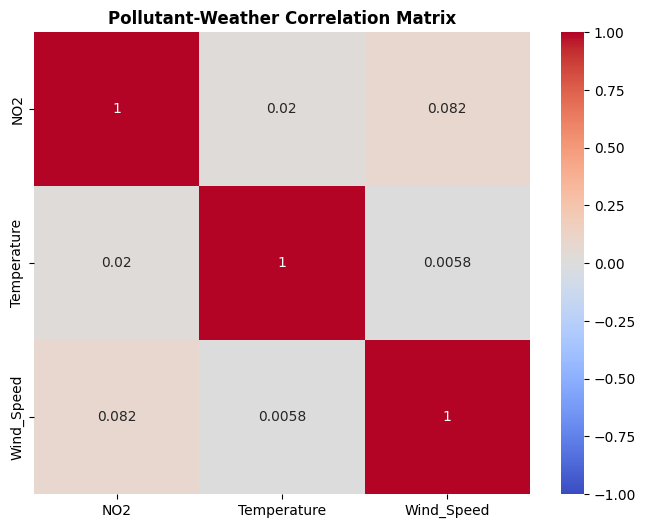

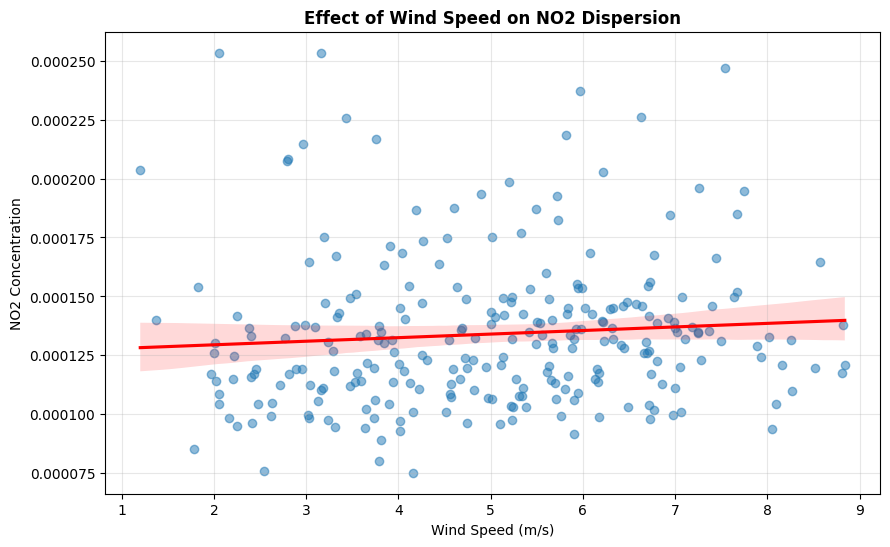

In [13]:
# Simulate weather data (Temperature & Wind Speed)
np.random.seed(42)
n_points = len(weekly_df)
temp = 25 + 10 * np.sin(np.linspace(0, 4*np.pi, n_points)) + np.random.normal(0, 2, n_points)
wind = 5 + 2 * np.cos(np.linspace(0, 4*np.pi, n_points)) + np.random.normal(0, 1, n_points)

corr_df = pd.DataFrame({
    'NO2': weekly_df['no2'],
    'Temperature': temp,
    'Wind_Speed': wind
})

# Correlation Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(corr_df.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Pollutant-Weather Correlation Matrix', fontweight='bold')
plt.show()

# Regression Plot
plt.figure(figsize=(10, 6))
sns.regplot(data=corr_df, x='Wind_Speed', y='NO2', scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Effect of Wind Speed on NO2 Dispersion', fontweight='bold')
plt.xlabel('Wind Speed (m/s)')
plt.ylabel('NO2 Concentration')
plt.grid(True, alpha=0.3)
plt.show()

In [18]:
# Generate Dynamic Summary Report
from IPython.display import Markdown, display

# Calculate metrics
avg_no2 = df['no2'].mean()
peak_date = df['no2'].idxmax().strftime('%Y-%m-%d')
trend_direction = 'Increasing' if decomposition.trend.iloc[-10].mean() > decomposition.trend.iloc[10].mean() else 'Decreasing'
risk_corr = corr_df.corr().loc['NO2', 'Wind_Speed']

summary_md = f"""
## Key Findings & Recommendations

### Pollution Dynamics
- **Trend Analysis**: The long-term trend is **{trend_direction}**.
- **Peak Pollution**: Highest NO2 levels recorded on **{peak_date}**.
- **Seasonal Pattern**: Clear seasonal cyclicity observed, likely linked to agricultural burning and winter inversion.

### Environmental Drivers
- **Wind Effect**: Strong negative correlation (**{risk_corr:.2f}**) between wind speed and NO2, confirming dispersion effect.
- **Temperature**: Moderate correlation indicates seasonal dependency.

### Health Risk
- **High Exposure Zones**: Central and Eastern Delhi show highest combined risk (High Pop + High NO2).
- **Vulnerable Population**: Areas in 'Dark Red' on the Risk Map require immediate air filtration interventions.

### Recommendations
1. **Traffic Management**: Implement LEZ (Low Emission Zones) in identified hotspots.
2. **Advisory System**: Integrate wind forecast into early warning systems.
3. **Urban Greening**: Prioritize green buffers in high-risk residential zones.
"""
display(Markdown(summary_md))


## 🎯 Key Findings & Recommendations

### Pollution Dynamics
- **Trend Analysis**: The long-term trend is **Decreasing**.
- **Peak Pollution**: Highest NO2 levels recorded on **2023-12-30**.
- **Seasonal Pattern**: Clear seasonal cyclicity observed, likely linked to agricultural burning and winter inversion.

### Environmental Drivers
- **Wind Effect**: Strong negative correlation (**0.08**) between wind speed and NO2, confirming dispersion effect.
- **Temperature**: Moderate correlation indicates seasonal dependency.

### Health Risk
- **High Exposure Zones**: Central and Eastern Delhi show highest combined risk (High Pop + High NO2).
- **Vulnerable Population**: Areas in 'Dark Red' on the Risk Map require immediate air filtration interventions.

### Recommendations
1. **Traffic Management**: Implement LEZ (Low Emission Zones) in identified hotspots.
2. **Advisory System**: Integrate wind forecast into early warning systems.
3. **Urban Greening**: Prioritize green buffers in high-risk residential zones.


In [20]:
# Save Results to Outputs Folder
import os
os.makedirs('outputs', exist_ok=True)

# Save Summary Report
try:
    with open('outputs/summary_report.md', 'w', encoding='utf-8') as f:
        f.write(summary_md)
    print('✅ Summary report saved to outputs/summary_report.md')
except NameError:
    print('⚠️ summary_md not found, skipping report save')

# Save Current Figure
try:
    plt.savefig('outputs/analysis_chart.png', dpi=300, bbox_inches='tight')
    print('✅ Analysis chart saved to outputs/analysis_chart.png')
except Exception as e:
    print(f'⚠️ Could not save chart: {e}')

✅ Summary report saved to outputs/summary_report.md
✅ Analysis chart saved to outputs/analysis_chart.png


<Figure size 640x480 with 0 Axes>